In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import fnmatch
from scipy.optimize import curve_fit

In [2]:
mpl.rcParams['figure.dpi'] = 150

In [36]:
def filter_files(path, pattern, Nmax=9000, pos_N=11):
    files = []
    # Iterate through the files in the specified directory
    for filename in os.listdir(path):
        if fnmatch.fnmatch(filename, pattern):
            parts = filename.split('_')
            N = int(parts[pos_N])
            if N <= Nmax:
                files.append((filename, int(parts[pos_N])))
    sorted_pairs = sorted(files, key=lambda x: x[1])  # Sort by the value at pos_N
    return sorted_pairs

In [31]:
def read_data_mu(path, filename, mu_extract, column_mu=0, column_sigma=1, column_ndiv=3, column_nmult=4,
                 column_total=6, skiprows=1):
    answ = []
    fin = open(f'{path}/{filename}', 'r')
    for _ in range(skiprows):
        fin.readline()
    while True:
        line = fin.readline()
        if not line:
            break
        data = line.split()
        mu = float(data[column_mu])
        if mu == mu_extract:
            sigma = float(data[column_sigma])
            ndiv = int(data[column_ndiv])
            total = int(data[column_total])
            nmult = int(data[column_nmult]) 
            answ.append([sigma, ndiv, nmult, total])
    fin.close()
    return np.array(answ)

In [35]:
def read_all_data_single_mu(path, pattern, mu, Nmax=9000):
    files = filter_files(path, pattern, Nmax=Nmax)
    data_mu = {}
    for filename, N in files:
        data = read_data_mu(path, filename, mu)
        data_mu[N] = data
    return data_mu

In [6]:
def sigmoid(x, a, b):
    return 1.0 / (1.0 + np.exp(-a * (x - b)))


def fit_sigmoid(sigma_data, fraction_data, error_in_fraction, maxfev=10000):
    try:
        popt, pcov = curve_fit(sigmoid, sigma_data, fraction_data, sigma=error_in_fraction, 
                               maxfev=maxfev, bounds=([0, 0], [np.inf, np.inf]))
        error_parameters = np.sqrt(np.diag(pcov))
        return popt, error_parameters
    except RuntimeError:
        print("Error: Sigmoid fit did not converge.")
        return None
    
def find_transition_fit(mu, sigma_data, fraction_data, error_in_fraction):
    popt, error_parameters = fit_sigmoid(sigma_data, fraction_data, error_in_fraction)
    _, b = popt
    _ , error_b = error_parameters
    if popt is not None and b > 0 and error_b < np.inf:
        return (b - error_b, b + error_b)
    else:
        print(f"Could not fit sigmoid for mu={mu}.")
        return None

In [42]:
def set_data_to_plot(path, pattern, mu, shift=False, Nmax=9000):
    data_mu = read_all_data_single_mu(path, pattern, mu, Nmax=Nmax)
    data_to_plot = {}
    for N in data_mu:
        data = data_mu[N]
        sigma_data = data[:, 0]
        ndiv_data = data[:, 1]
        nmult_data = data[:, 2]
        total_data = data[:, 3]
        fraction_data_div = ndiv_data / total_data
        error_in_fraction_div = np.sqrt(fraction_data_div * (1 - fraction_data_div) / total_data)
        if shift:
            fraction_data_mult = nmult_data / total_data
            error_in_fraction_mult = np.sqrt(fraction_data_mult * (1 - fraction_data_mult) / total_data)
            sigma_data_fit = sigma_data[error_in_fraction_mult > 0]
            fraction_data_mult = fraction_data_mult[error_in_fraction_mult > 0]
            error_in_fraction_mult = error_in_fraction_mult[error_in_fraction_mult > 0]
            transition_mult = find_transition_fit(mu, sigma_data_fit, fraction_data_mult, error_in_fraction_mult)
            if transition_mult is not None:
                sigma_data -= transition_mult[0]
        fraction_data_only_mult = (nmult_data - ndiv_data) / total_data
        error_in_fraction_only_mult = np.sqrt(fraction_data_only_mult * (1 - fraction_data_only_mult) / total_data)
        data_to_plot[N] = [sigma_data, fraction_data_div, error_in_fraction_div, fraction_data_only_mult, error_in_fraction_only_mult]
    return data_to_plot

In [27]:
def plot_data(data_to_plot, column_y=3, column_error=4, ylabel="P(mult)", shift=False, figname=None):
    plt.figure()
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for idx, N in enumerate(data_to_plot):
        color = color_cycle[idx % len(color_cycle)]
        data = data_to_plot[N]
        sigma_values = data[0]
        y_values = data[column_y]
        errors = data[column_error]
        plt.scatter(sigma_values, y_values, label=f'N={N}', color=color, s=10)
        plt.errorbar(sigma_values, y_values, yerr=errors, color=color, capsize=2, alpha=0.5)
    if shift:
        plt.xlabel(r'$\sigma - \sigma_{c}$')
    else:
        plt.xlabel(r'$\sigma$')
    plt.ylabel(ylabel)
    plt.legend()
    if figname is not None:
        plt.savefig(figname, dpi=400)

In [9]:
eps = "0.0"
lda = "1e-06"
c = "3.00"
T = "0.0"
tol_fixed_point = "1e-08"

# path = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/"
path = "/mnt/d/Research/Ecology/Langevin/Results/"

pattern = f"Lotka-Volterra_summary_epsilon_{eps}_Partially_AsymGauss_lambda_{lda}_tol_{tol_fixed_point}_N_*_c_{c}_T_{T}.txt"

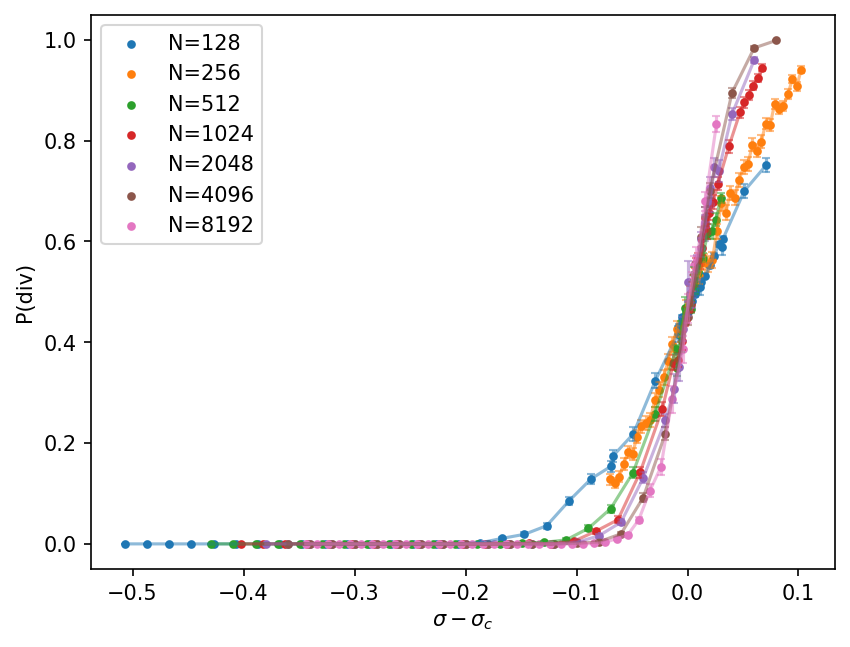

In [44]:
mu = 0
column_y = 1
column_error = 2
ylabel = "P(div)"
shift = True
Nmax = 9000
data_to_plot = set_data_to_plot(path, pattern, mu, shift=shift, Nmax=Nmax)
plot_data(data_to_plot, column_y=column_y, column_error=column_error, ylabel=ylabel, shift=shift)

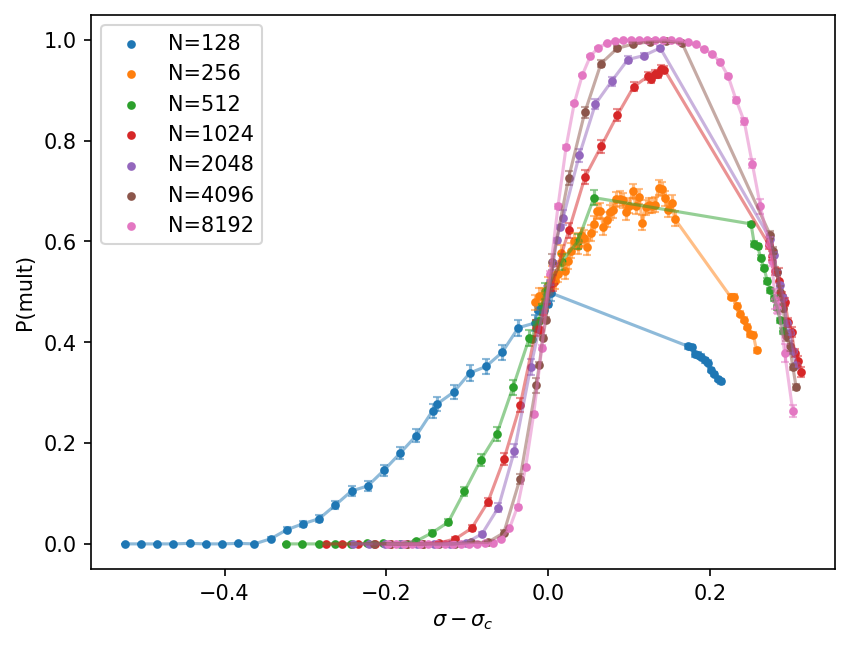

In [46]:
mu = 0.270
column_y = 3
column_error = 4
ylabel = "P(mult)"
shift = True
Nmax = 9000
data_to_plot = set_data_to_plot(path, pattern, mu, shift=shift, Nmax=Nmax)
plot_data(data_to_plot, column_y=column_y, column_error=column_error, ylabel=ylabel, shift=shift)

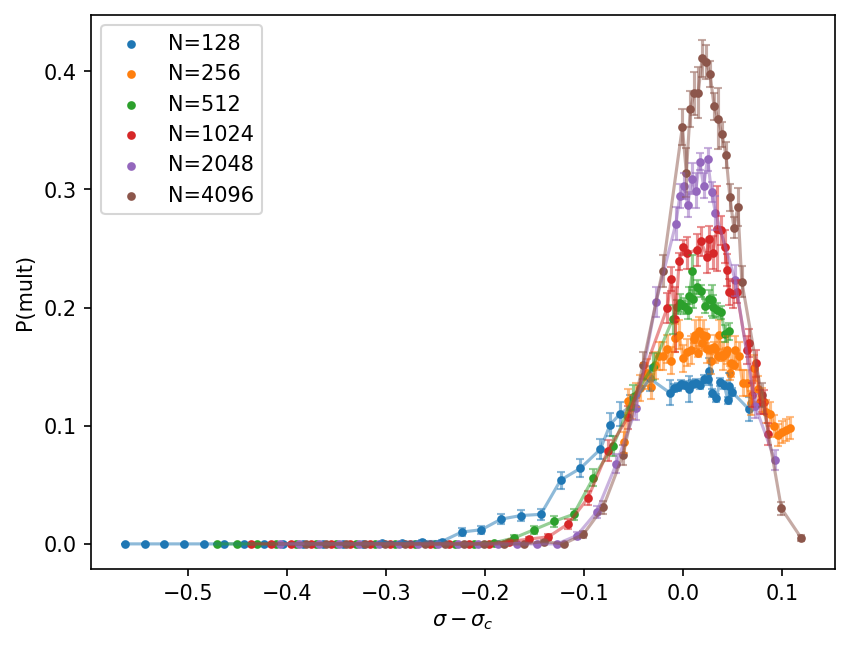

In [49]:
mu = 0.102
column_y = 3
column_error = 4
ylabel = "P(mult)"
shift = True
Nmax = 7000
data_to_plot = set_data_to_plot(path, pattern, mu, shift=shift, Nmax=Nmax)
plot_data(data_to_plot, column_y=column_y, column_error=column_error, ylabel=ylabel, shift=shift)